In [1]:
import cv2
import json
from matplotlib import pyplot as plt
import numpy as np
import os
import random
import time

# import a lot of things from keras:
# sequential model
from keras.models import Sequential

# layers
from keras.layers import Input, Dense, Dropout, Flatten, Conv2D, MaxPooling2D, RandomFlip, RandomRotation, RandomContrast, RandomBrightness

# loss function
from keras.metrics import categorical_crossentropy

# callback functions
from keras.callbacks import ReduceLROnPlateau, EarlyStopping

# convert data to categorial vector representation
from keras.utils import to_categorical

# nice progress bar for loading data
from tqdm.notebook import tqdm

# helper function for train/test split
from sklearn.model_selection import train_test_split

# import confusion matrix helper function
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# import pre-trained model
from keras.applications.vgg16 import VGG16

CONDITIONS = ['dislike', 'fist', 'like', 'ok', 'one', 'peace', 'rock', 'stop', 'three', 'two_up']

# image size
IMG_SIZE = 64
SIZE = (IMG_SIZE, IMG_SIZE)

# number of color channels we want to use
# set to 1 to convert to grayscale
# set to 3 to use color images
COLOR_CHANNELS = 3

## helper function to load and parse annotations

In [2]:
annotations = dict()

for condition in CONDITIONS:
    with open(f'../data/_annotations/{condition}.json') as f:
        annotations[condition] = json.load(f)

## helper function to pre-process images (color channel conversion and resizing)

In [3]:
def preprocess_image(img):
    if COLOR_CHANNELS == 1:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_resized = cv2.resize(img, SIZE)
    return img_resized

## load images and annotations

In [4]:
images = [] # stores actual image data
labels = [] # stores labels (as integer - because this is what our network needs)
label_names = [] # maps label ints to their actual categories so we can understand predictions later

# loop over all conditions
# loop over all files in the condition's directory
# read the image and corresponding annotation
# crop image to the region of interest
# preprocess image
# store preprocessed image and label in corresponding lists
for condition in CONDITIONS:
    for filename in tqdm(os.listdir(f'../data/{condition}')):
        UID = filename.split('.')[0]
        img = cv2.imread(f'../data/{condition}/{filename}')
        
        # get annotation from the dict we loaded earlier
        try:
            annotation = annotations[condition][UID]
        except Exception as e:
            print(e)
            continue
        
        # iterate over all hands annotated in the image
        for i, bbox in enumerate(annotation['bboxes']):
            # annotated bounding boxes are in the range from 0 to 1
            # therefore we have to scale them to the image size
            x1 = int(bbox[0] * img.shape[1])
            y1 = int(bbox[1] * img.shape[0])
            w = int(bbox[2] * img.shape[1])
            h = int(bbox[3] * img.shape[0])
            x2 = x1 + w
            y2 = y1 + h
            
            # crop image to the bounding box and apply pre-processing
            crop = img[y1:y2, x1:x2]
            preprocessed = preprocess_image(crop)
            
            # get the annotated hand's label
            # if we have not seen this label yet, add it to the list of labels
            label = annotation['labels'][i]
            if label == "no_gesture":
                continue
            if label not in label_names:
                label_names.append(label)
            
            label_index = label_names.index(label)
            
            images.append(preprocessed)
            labels.append(label_index)

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

## let's have a look at one of the images

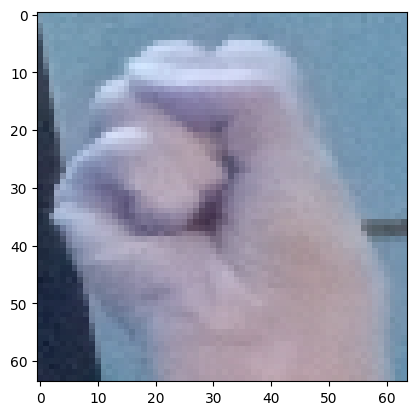

In [5]:
plt.imshow(random.sample(images, 1)[0])

## split data set into train and test

x is for the actual data, y is for the label (this is convention)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

print(len(X_train))
print(len(X_test))
print(len(y_train))
print(len(y_test))

2000
500
2000
500


## transform data sets into a format compatible with our neural network

image data has to be a numpy array with following dimensions: [image_id, y_axis, x_axis, color_channels]

furthermore, scale all values to a range of 0 to 1

training data has to be converted to a categorial vector ("one hot"):

[3] --> [0, 0, 0, 1, 0, ..., 0]

In [7]:
X_train = np.array(X_train).astype('float32')
X_train = X_train / 255.

X_test = np.array(X_test).astype('float32')
X_test = X_test / 255.

y_train_one_hot = to_categorical(y_train)
y_test_one_hot = to_categorical(y_test)

train_label = y_train_one_hot
test_label = y_test_one_hot

X_train = X_train.reshape(-1, IMG_SIZE, IMG_SIZE, COLOR_CHANNELS)
X_test = X_test.reshape(-1, IMG_SIZE, IMG_SIZE, COLOR_CHANNELS)

print(X_train.shape, X_test.shape, train_label.shape, test_label.shape)

(2000, 64, 64, 3) (500, 64, 64, 3) (2000, 10) (500, 10)


In [8]:
# variables for hyperparameters
batch_size = 8
epochs = 50
num_classes = len(label_names)
activation = 'relu'
activation_conv = 'leaky_relu'  # LeakyReLU
layer_count = 2
num_neurons = 64

# define model structure
# with keras, we can use a model's add() function to add layers to the network one by one
model = Sequential()

# data augmentation (this can also be done beforehand - but don't augment the test dataset!)
model.add(RandomFlip('horizontal'))
model.add(RandomContrast(0.1))
#model.add(RandomBrightness(0.1))
#model.add(RandomRotation(0.2))

# first, we add some convolution layers followed by max pooling
model.add(Conv2D(64, kernel_size=(9, 9), activation=activation_conv, input_shape=(SIZE[0], SIZE[1], COLOR_CHANNELS), padding='same'))
model.add(MaxPooling2D(pool_size=(4, 4), padding='same'))

model.add(Conv2D(32, (5, 5), activation=activation_conv, padding='same'))
model.add(MaxPooling2D(pool_size=(3, 3), padding='same'))

model.add(Conv2D(32, (3, 3), activation=activation_conv, padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2), padding='same'))

# dropout layers can drop part of the data during each epoch - this prevents overfitting
model.add(Dropout(0.2))

# after the convolution layers, we have to flatten the data so it can be fed into fully connected layers
model.add(Flatten())

# add some fully connected layers ("Dense")
for i in range(layer_count - 1):
    model.add(Dense(num_neurons, activation=activation))

model.add(Dense(num_neurons, activation=activation))

# for classification, the last layer has to use the softmax activation function, which gives us probabilities for each category
model.add(Dense(num_classes, activation='softmax'))

# specify loss function, optimizer and evaluation metrics
# for classification, categorial crossentropy is used as a loss function
# use the adam optimizer unless you have a good reason not to
model.compile(loss=categorical_crossentropy, optimizer="adam", metrics=['accuracy'])

# define callback functions that react to the model's behavior during training
# in this example, we reduce the learning rate once we get stuck and early stopping
# to cancel the training if there are no improvements for a certain amount of epochs
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=0.0001)
stop_early = EarlyStopping(monitor='val_loss', patience=3)

c:\Users\Felix\Documents\Uni\ITT\assignment-05-cnn-Alphazerfall\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Train model from the course

In [9]:
history = model.fit(
    X_train,
    train_label,
    batch_size=batch_size,
    epochs=epochs,
    verbose=1,
    validation_data=(X_test, test_label),
    callbacks=[reduce_lr, stop_early]
)

Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 43s 111ms/step - accuracy: 0.0955 - loss: 2.3164 - val_accuracy: 0.1000 - val_loss: 2.3074 - learning_rate: 0.0010
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 15s 59ms/step - accuracy: 0.1355 - loss: 2.2822 - val_accuracy: 0.1960 - val_loss: 2.1844 - learning_rate: 0.0010
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 23s 69ms/step - accuracy: 0.2460 - loss: 2.0899 - val_accuracy: 0.3480 - val_loss: 1.8259 - learning_rate: 0.0010
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 20s 80ms/step - accuracy: 0.3835 - loss: 1.7211 - val_accuracy: 0.3740 - val_loss: 1.7471 - learning_rate: 0.0010
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 17s 69ms/step - accuracy: 0.4880 - loss: 1.4465 - val_accuracy: 0.5420 - val_loss: 1.3325 - learning_rate: 0.0010
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 26s 102ms/step - accuracy: 0.5760 - loss: 1.1980 - val_accuracy: 0.6320 - val_loss: 1.1348 - learning_rate: 0.0010
Epoch 7/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 39s 94ms/step - accuracy: 0.6455 -

In [10]:
# let's have a look at our model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (8, 64, 64, 3)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (8, 64, 64, 3)         │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (8, 64, 64, 64)        │        15,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (8, 16, 16, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (8, 16, 16, 32)        │        51,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (8, 6, 6, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (8, 6, 6, 32)          │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (8, 3, 3, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (8, 3, 3, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (8, 288)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (8, 64)                │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (8, 64)                │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (8, 10)                │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 298,208 (1.14 MB)

 Trainable params: 99,402 (388.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 198,806 (776.59 KB)

## Accuracy and loss of the training process

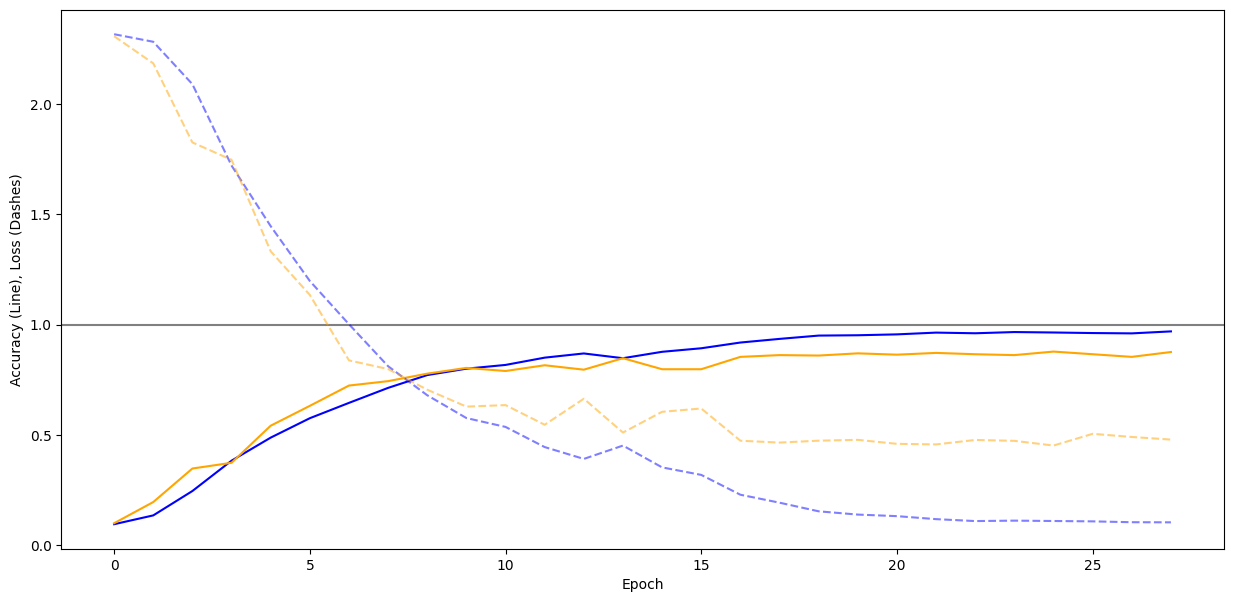

In [11]:
loss = history.history['loss']
val_loss = history.history['val_loss']
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

fig = plt.figure(figsize=(15, 7))
ax = plt.gca()

ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (Line), Loss (Dashes)')

ax.axhline(1, color='gray')

plt.plot(accuracy, color='blue')
plt.plot(val_accuracy, color='orange')
plt.plot(loss, '--', color='blue', alpha=0.5)
plt.plot(val_loss, '--', color='orange', alpha=0.5)

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 114ms/step
before [[2.2867061e-06 1.7507421e-06 7.0149536e-06 ... 2.9787379e-06
  5.7582200e-01 3.4491837e-04]
 [4.1398853e-11 8.1061206e-11 6.0527225e-07 ... 6.6570675e-13
  8.5382548e-05 1.5888221e-04]
 [2.7957053e-27 2.0093230e-17 2.7056900e-03 ... 5.3622563e-31
  6.4144910e-19 1.8534079e-08]
 ...
 [5.3174298e-30 5.8169290e-23 1.0000000e+00 ... 3.6405560e-24
  8.7202335e-22 9.5229160e-21]
 [9.9992323e-01 5.7381886e-09 3.3898418e-14 ... 2.3039242e-14
  1.2190121e-07 3.2030295e-10]
 [4.7170374e-06 9.6523472e-05 2.7288707e-02 ... 8.4226165e-04
  3.4250864e-01 5.6933187e-04]]
probabilities [8 4 4 9 6 2 6 4 0 9 1 0 3 4 2 3 5 4 1 4 8 2 8 9 0 3 8 4 5 2 5 0 4 3 3 4 7
 5 7 8 9 8 7 5 3 6 5 0 7 3 1 7 2 0 8 0 4 5 7 5 4 4 1 8 0 4 5 0 2 1 2 9 9 9
 5 4 6 9 5 0 7 1 3 4 8 7 8 1 7 7 7 2 0 3 2 5 4 6 4 0 8 4 8 7 2 4 1 7 5 2 5
 9 5 5 3 3 6 6 7 3 1 0 0 7 8 1 3 8 5 1 1 6 8 7 4 1 4 2 1 1 7 4 4 5 4 5 5 0
 2 8 1 5 2 3 3 7 7 6 0 7 5 7 2 0 0 9 3 9 5 6 8 3 2 5 7 3 3 1 7 2 6 1 1 5 2

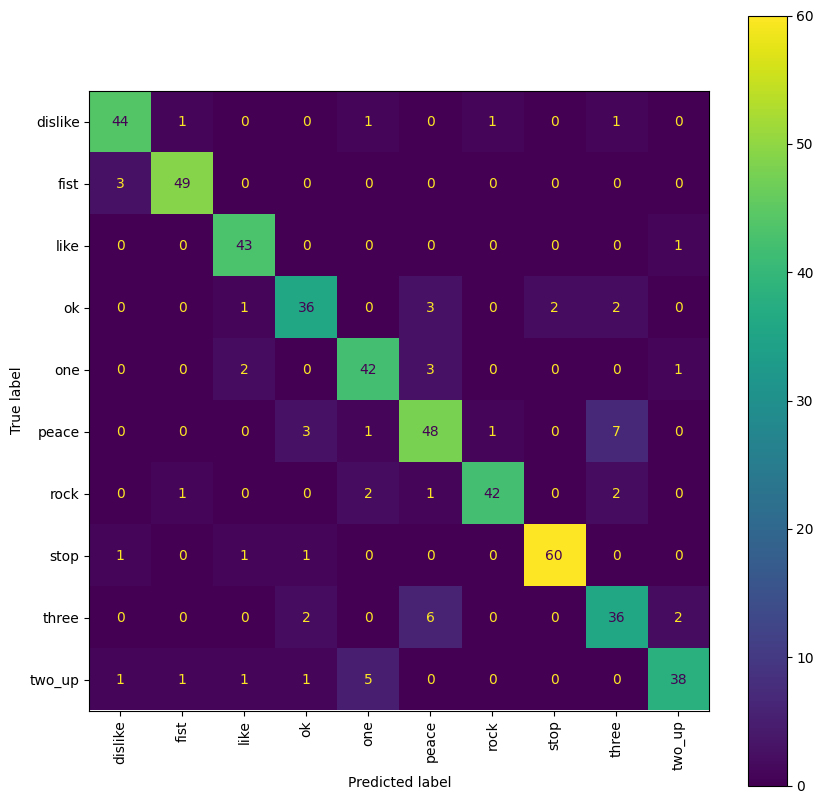

In [12]:
# let the model make predictions for our training data
y_predictions = model.predict(X_test)

# we get a 2D numpy array with probabilities for each category
print('before', y_predictions)

# to build a confusion matrix, we have to convert it to classifications
# this can be done by using the argmax() function to set the probability to 1 and the rest to 0
y_predictions = np.argmax(y_predictions, axis=1)

print('probabilities', y_predictions)

# create and plot confusion matrix
conf_matrix = confusion_matrix(y_test, y_predictions)

fig = plt.figure(figsize=(10, 10))

ConfusionMatrixDisplay(conf_matrix, display_labels=label_names).plot(ax=plt.gca())

plt.xticks(rotation=90, ha='center')
pass

## Comparison of kernel size for the convolution layer

### Approach & Assumptions

The original course notebook used only 2 gesture categories (`like`, `stop`). Here all 10 available categories are used (`dislike`, `fist`, `like`, `ok`, `one`, `peace`, `rock`, `stop`, `three`, `two_up`), since a harder problem should show the effect of kernel size more clearly.

All other hyperparameters are kept fixed (`batch_size=8`, `activation_conv=leaky_relu`, `activation=relu`, `layer_count=2`, `num_neurons=64`). The kernel size is changed uniformly across all three convolution layers to isolate its effect.

All runs train for the same fixed number of epochs (25) without early stopping. Only `ReduceLROnPlateau` is kept so the learning rate can adapt the same way in all runs. Without this, small kernels that converge quickly would train for 20 to 30 epochs while large kernels that fail to learn would stop after 5, which would make the comparison meaningless.

Each kernel size is trained 5 times and the results are reported as mean and standard deviation, since large kernels turned out to be very sensitive to random initialisation. In a first single-run test, 13x13 looked like it performed well (~0.82) while 9x9 and 11x11 failed completely (~0.10). After repeating the runs the picture reversed: 13x13 consistently failed while 9x9 and 11x11 just showed high variance. So a single run would have been pure luck.

**Tested values:** 3x3, 5x5, 7x7, 9x9, 11x11, 13x13

**Assumptions before training:**
- Accuracy should decrease with larger kernels.
- Inference time should increase with kernel size.
- Parameter count should grow quadratically with kernel size.

In [ ]:
EXPERIMENT_EPOCHS = 25  # fixed epoch count

def build_model(kernel_size):
    m = Sequential()
    m.add(RandomFlip('horizontal'))
    m.add(RandomContrast(0.1))
    m.add(Conv2D(64, kernel_size=kernel_size, activation=activation_conv, input_shape=(IMG_SIZE, IMG_SIZE, COLOR_CHANNELS), padding='same'))
    m.add(MaxPooling2D(pool_size=(4, 4), padding='same'))
    m.add(Conv2D(32, kernel_size=kernel_size, activation=activation_conv, padding='same'))
    m.add(MaxPooling2D(pool_size=(3, 3), padding='same'))
    m.add(Conv2D(32, kernel_size=kernel_size, activation=activation_conv, padding='same'))
    m.add(MaxPooling2D(pool_size=(2, 2), padding='same'))
    m.add(Dropout(0.2))
    m.add(Flatten())
    for _ in range(layer_count - 1):
        m.add(Dense(num_neurons, activation=activation))
    m.add(Dense(num_neurons, activation=activation))
    m.add(Dense(num_classes, activation='softmax'))
    m.compile(loss=categorical_crossentropy, optimizer='adam', metrics=['accuracy'])
    return m


def train_model(model):
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=0.0001)
    return model.fit(
        X_train, train_label,
        batch_size=batch_size,
        epochs=EXPERIMENT_EPOCHS,
        verbose=1,
        validation_data=(X_test, test_label),
        callbacks=[reduce_lr],
    )


def measure_inference_time(model, runs=5):
    times = []
    for _ in range(runs):
        t0 = time.perf_counter()
        model.predict(X_test, verbose=0)
        times.append(time.perf_counter() - t0)
    return (min(times) / len(X_test)) * 1000


In [15]:
kernel_sizes = [3, 5, 7, 9, 11, 13]
NUM_RUNS = 5
results = []

for ks in kernel_sizes:
    run_accuracies = []
    run_inf_times = []
    run_histories = []
    param_count = None

    for run in range(NUM_RUNS):
        print(f"\n-- Kernel size {ks}x{ks}, run {run+1}/{NUM_RUNS} --")
        m = build_model(kernel_size=(ks, ks))
        hist = train_model(m)
        if param_count is None:
            param_count = m.count_params()

        run_accuracies.append(max(hist.history['val_accuracy']))
        run_inf_times.append(measure_inference_time(m))
        run_histories.append(hist.history['val_accuracy'])

    max_len = max(len(h) for h in run_histories)
    padded = [h + [h[-1]] * (max_len - len(h)) for h in run_histories]
    mean_history = np.mean(padded, axis=0).tolist()
    std_history = np.std(padded, axis=0).tolist()

    results.append({
        'kernel_size': ks,
        'val_accuracy': np.mean(run_accuracies),
        'val_accuracy_std': np.std(run_accuracies),
        'inference_ms': np.mean(run_inf_times),
        'inference_ms_std': np.std(run_inf_times),
        'param_count': param_count,
        'history': mean_history,
        'history_std': std_history,
        'run_histories': run_histories,
    })
    print(f"  -> val_accuracy={np.mean(run_accuracies):.3f} ± {np.std(run_accuracies):.3f}  "
          f"inference={np.mean(run_inf_times):.2f} ms/img  params={param_count:,}")


-- Kernel size 3x3, run 1/5 --
Epoch 1/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - accuracy: 0.1125 - loss: 2.3039 - val_accuracy: 0.0880 - val_loss: 2.3002 - learning_rate: 0.0010
Epoch 2/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.2310 - loss: 2.0430 - val_accuracy: 0.3260 - val_loss: 1.6590 - learning_rate: 0.0010
Epoch 3/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.4680 - loss: 1.4460 - val_accuracy: 0.5500 - val_loss: 1.1544 - learning_rate: 0.0010
Epoch 4/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.6405 - loss: 1.0333 - val_accuracy: 0.6640 - val_loss: 0.9319 - learning_rate: 0.0010
Epoch 5/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - accuracy: 0.7320 - loss: 0.7893 - val_accuracy: 0.7920 - val_loss: 0.7021 - learning_rate: 0.0010
Epoch 6/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.7900 - loss: 0.6333 - val_accuracy: 0.7500 - val_loss: 0.7265 - learning_rate: 0.0010
Epoch 7/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/

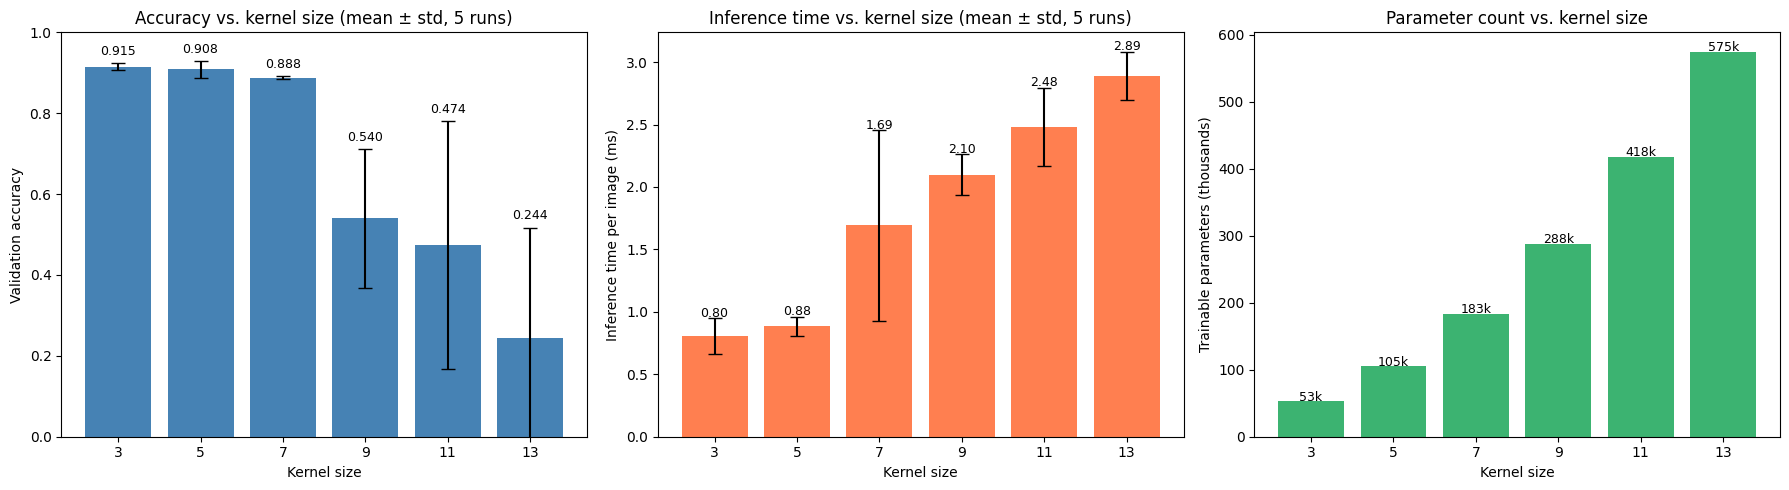


  Kernel   Val acc     Std    ms/img     Std      Params
       3     0.915   0.009      0.80    0.14      52,810
       5     0.908   0.021      0.88    0.08     105,034
       7     0.888   0.004      1.69    0.76     183,370
       9     0.540   0.171      2.10    0.17     287,818
      11     0.474   0.307      2.48    0.31     418,378
      13     0.244   0.273      2.89    0.19     575,050


In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

ks_labels = [str(k) for k in kernel_sizes]

ax1.bar(ks_labels, [r['val_accuracy'] for r in results],
        yerr=[r['val_accuracy_std'] for r in results],
        color='steelblue', capsize=5)
ax1.set_xlabel('Kernel size')
ax1.set_ylabel('Validation accuracy')
ax1.set_title(f'Accuracy vs. kernel size (mean ± std, {NUM_RUNS} runs)')
ax1.set_ylim(0, 1)
for i, r in enumerate(results):
    ax1.text(i, r['val_accuracy'] + r['val_accuracy_std'] + 0.02,
             f"{r['val_accuracy']:.3f}", ha='center', fontsize=9)

ax2.bar(ks_labels, [r['inference_ms'] for r in results],
        yerr=[r['inference_ms_std'] for r in results],
        color='coral', capsize=5)
ax2.set_xlabel('Kernel size')
ax2.set_ylabel('Inference time per image (ms)')
ax2.set_title(f'Inference time vs. kernel size (mean ± std, {NUM_RUNS} runs)')
for i, r in enumerate(results):
    ax2.text(i, r['inference_ms'] + r['inference_ms_std'] + 0.01,
             f"{r['inference_ms']:.2f}", ha='center', fontsize=9)

ax3.bar(ks_labels, [r['param_count'] / 1000 for r in results], color='mediumseagreen')
ax3.set_xlabel('Kernel size')
ax3.set_ylabel('Trainable parameters (thousands)')
ax3.set_title('Parameter count vs. kernel size')
for i, r in enumerate(results):
    ax3.text(i, r['param_count'] / 1000 + 1,
             f"{r['param_count'] / 1000:.0f}k", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('kernel_size_results.png', dpi=150)
plt.show()

print(f"\n{'Kernel':>8}  {'Val acc':>8}  {'Std':>6}  {'ms/img':>8}  {'Std':>6}  {'Params':>10}")
for r in results:
    print(f"{str(r['kernel_size']):>8}  {r['val_accuracy']:>8.3f}  "
          f"{r['val_accuracy_std']:>6.3f}  {r['inference_ms']:>8.2f}  "
          f"{r['inference_ms_std']:>6.2f}  {r['param_count']:>10,}")


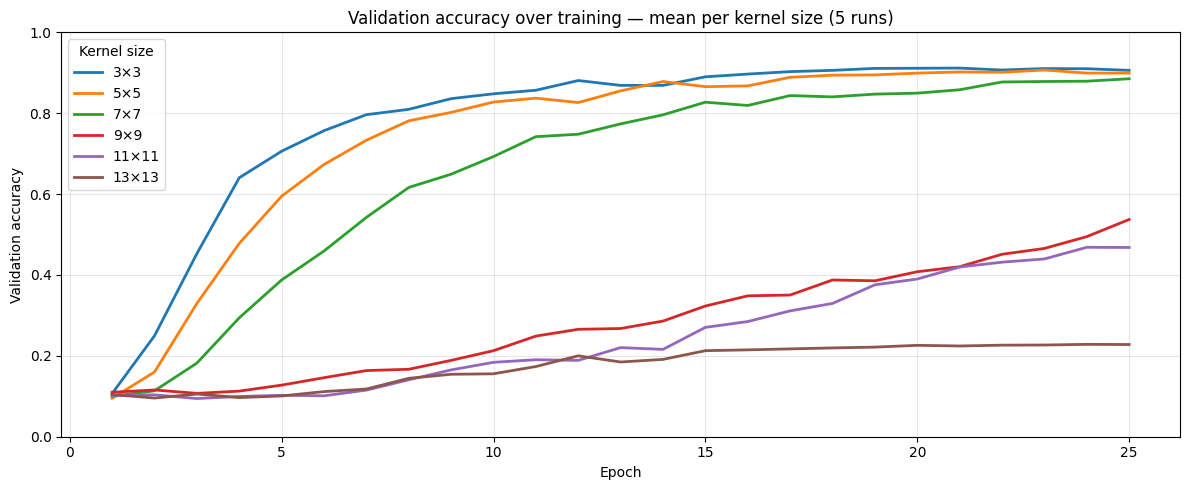

In [20]:
fig, ax = plt.subplots(figsize=(12, 5))

for r in results:
    mean = np.array(r['history'])
    ax.plot(range(1, len(mean) + 1), mean, linewidth=2,
            label=f"{r['kernel_size']}×{r['kernel_size']}")

ax.set_xlabel('Epoch')
ax.set_ylabel('Validation accuracy')
ax.set_title(f'Validation accuracy over training — mean per kernel size ({NUM_RUNS} runs)')
ax.set_ylim(0, 1)
ax.legend(title='Kernel size')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('kernel_size_accuracy_curves_mean.png', dpi=150)
plt.show()


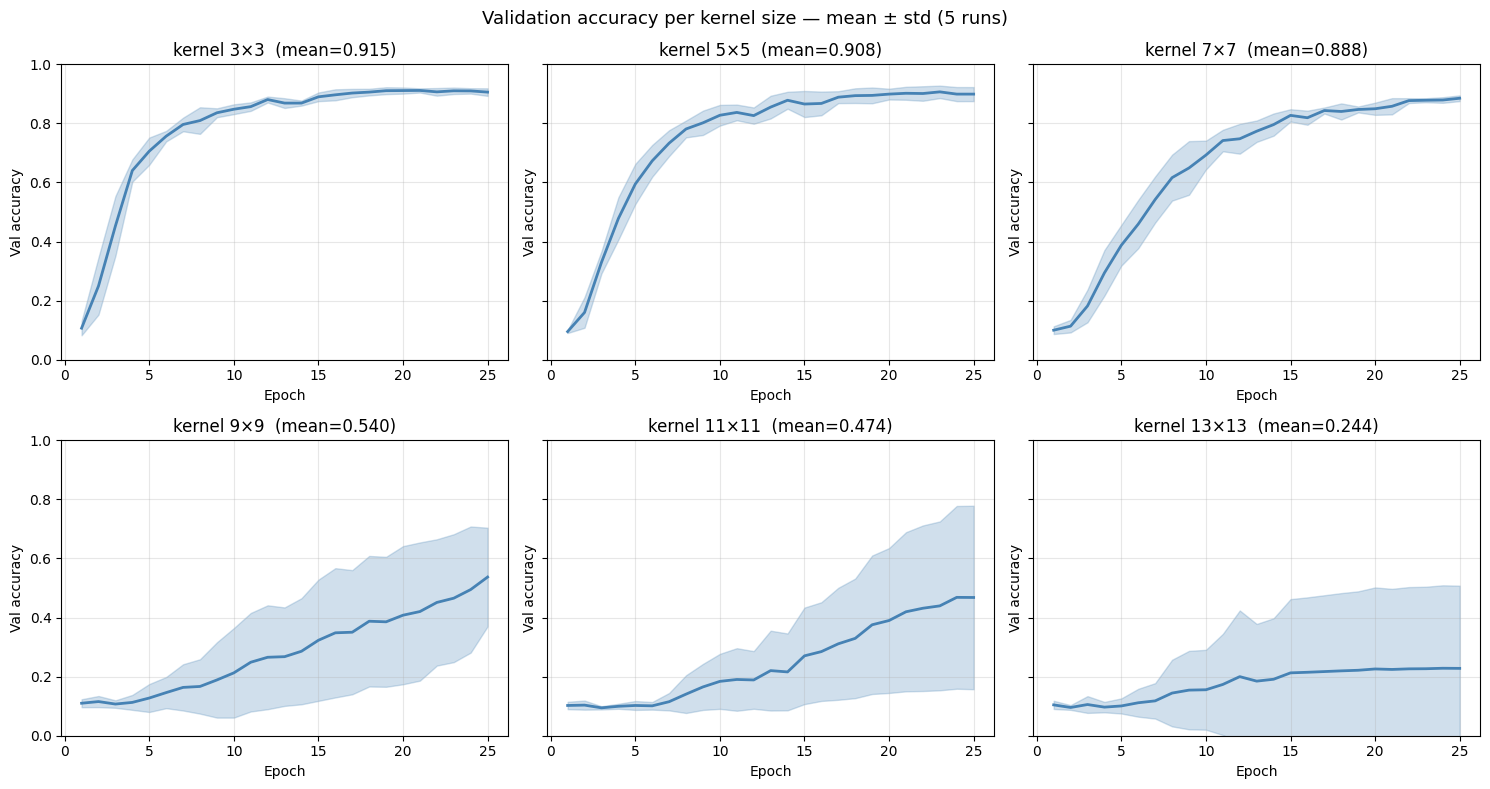

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)

for ax, r in zip(axes.flat, results):
    mean = np.array(r['history'])
    std  = np.array(r['history_std'])
    xs   = range(1, len(mean) + 1)

    ax.plot(xs, mean, linewidth=2, color='steelblue')
    ax.fill_between(xs, mean - std, mean + std, alpha=0.25, color='steelblue')
    ax.set_title(f"kernel {r['kernel_size']}×{r['kernel_size']}  (mean={r['val_accuracy']:.3f})")
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Val accuracy')
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Validation accuracy per kernel size — mean ± std ({NUM_RUNS} runs)', fontsize=13)
plt.tight_layout()
plt.savefig('kernel_size_accuracy_curves.png', dpi=150)
plt.show()

### Findings & Discussion

**Accuracy:** Small kernels (3x3 to 7x7) worked best, all reaching around 90% validation accuracy and converging reliably. From 9x9 on, accuracy dropped sharply. The large kernels were also very unstable, some runs learned something while others got stuck near random guessing, which is visible in the large error bars. This is why averaging over multiple runs was important, a single run would have been misleading.

**Inference time and parameters:** Both grow with kernel size as expected. The parameter count grows roughly quadratically because the kernel area scales with the width squared.

**Explanation:** The input images are only 64x64 and get pooled aggressively after each convolution layer. A 9x9 or larger kernel covers a big part of the feature map at once, so the network can no longer pick up small local patterns like finger edges, which is exactly what is needed to tell hand gestures apart.

**Conclusion:** I assumed accuracy would decrease gradually with kernel size, but instead there is a sharp break between 7x7 and 9x9. Kernel size 3x3 is the clear winner with the best accuracy, shortest inference time and fewest parameters. This also matches common practice, since modern CNN architectures almost always use small odd-sized kernels, usually 3x3, as explained in [this post](https://medium.com/data-science/deciding-optimal-filter-size-for-cnns-d6f7b56f9363).
